# Assignment 5.1
## Build an Explainable Bayesian Network for Heart Failure Prediction

In real medical AI systems today, doctors and regulators frequently reject black-box models (even if they are slightly more accurate) because they cannot explain why a patient was classified as high-risk. Bayesian Networks solve this problem and are still used in clinical decision support tools.

Your assignment is to use the Heart Failure Prediction dataset (https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) to do the following:

1. Exploratory Data Analysis
    * Produce at least four insightful plots
    * Write 3–5 sentences summarising the most important risk factors you observe

### Data source and reproducibility
The analysis uses the [Kaggle Heart Failure Prediction dataset, version 1](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/versions/1). Despite its title, the target is **presence of heart disease**, not death or future heart failure. Run this notebook from its assignment folder. Dependencies are in `requirements.txt`; use `%pip install -r requirements.txt` if needed.

The four EDA plots describe sample associations. The dataset contains 918 patients, no explicit nulls, 172 zero cholesterol readings, and one zero resting BP reading. Zero BP and cholesterol are treated as unknown measurements for modeling; valid zero Oldpeak measurements remain. No patients are removed. Group counts help identify sparse comparisons.

In [1]:
from pathlib import Path
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter


#importing dataset


# The path is the filename inside the Kaggle dataset, not an empty string.
csv_path = Path("heart.csv")
if csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    df = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "fedesoriano/heart-failure-prediction/versions/1",
        "heart.csv",
    )
    df.to_csv(csv_path, index=False)
print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2]:
numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
display(df.isna().sum().rename("Missing values").to_frame())
display(df[numeric_cols].describe())
display(df[numeric_cols].eq(0).sum().rename("Zero values").to_frame())
print("Duplicate rows:", df.duplicated().sum())
print("Columns:", df.columns.tolist())
# These four plots use no BP or cholesterol values; no rows are dropped or imputed.


,Missing values
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,136.809368,0.887364
std,9.432617,18.514154,109.384145,25.460334,1.066570
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


,Zero values
Age,0
RestingBP,1
Cholesterol,172
MaxHR,0
Oldpeak,368


Duplicate rows: 0
Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from pathlib import Path

plt.close("all")

plot_dir = Path("plots")
plot_dir.mkdir(exist_ok=True)
plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})
colors = ["#3979A8", "#C35A45"]


def save_plot(fig, filename):
    fig.tight_layout()
    fig.savefig(plot_dir / filename, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)


Plot 1: Do the age distributions overlap? Compare their shapes; each outcome group is normalized separately.

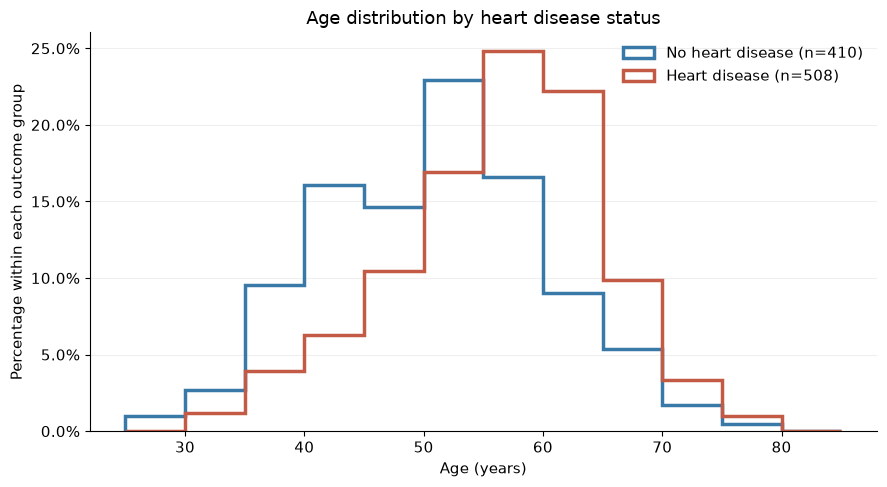

In [4]:
# Common bin edges and within-class percentages allow a fair shape comparison.
fig, ax = plt.subplots(figsize=(9, 5))
bins = list(range(25, 86, 5))
for outcome, label, color in [(0, "No heart disease", colors[0]),
                              (1, "Heart disease", colors[1])]:
    ages = df.loc[df["HeartDisease"].eq(outcome), "Age"].dropna()
    ax.hist(ages, bins=bins, weights=[100 / len(ages)] * len(ages),
            histtype="step", linewidth=2.5, color=color,
            label=f"{label} (n={len(ages)})")
ax.set(title="Age distribution by heart disease status",
       xlabel="Age (years)", ylabel="Percentage within each outcome group")
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)

save_plot(fig, "01_age_by_heart_disease.png")

Plot 2: Compare within-category percentages rather than raw counts. Which categories have smaller samples?

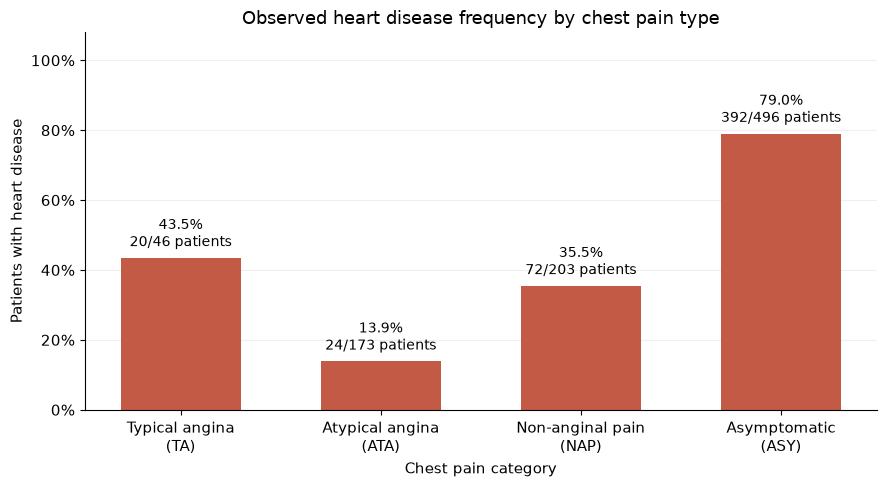

In [5]:
# Mean of a binary 0/1 target equals the fraction with HeartDisease=1.
order = ["TA", "ATA", "NAP", "ASY"]
stats = df.groupby("ChestPainType")["HeartDisease"].agg(["mean", "count", "sum"]).reindex(order)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(order, stats["mean"] * 100, color=colors[1], width=0.6)
for bar, row in zip(bars, stats.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{row.mean:.1%}\n{int(row.sum)}/{int(row.count)} patients",
            ha="center", va="bottom", fontsize=10)
ax.set_xticks(range(4), ["Typical angina\n(TA)", "Atypical angina\n(ATA)",
                       "Non-anginal pain\n(NAP)", "Asymptomatic\n(ASY)"])
ax.set(title="Observed heart disease frequency by chest pain type",
       xlabel="Chest pain category", ylabel="Patients with heart disease", ylim=(0, 108))
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

save_plot(fig, "02_chest_pain_heart_disease_rate.png")


Plot 3: Compare angina states within each ST slope. These are empirical conditional frequencies, not Bayesian network query results.

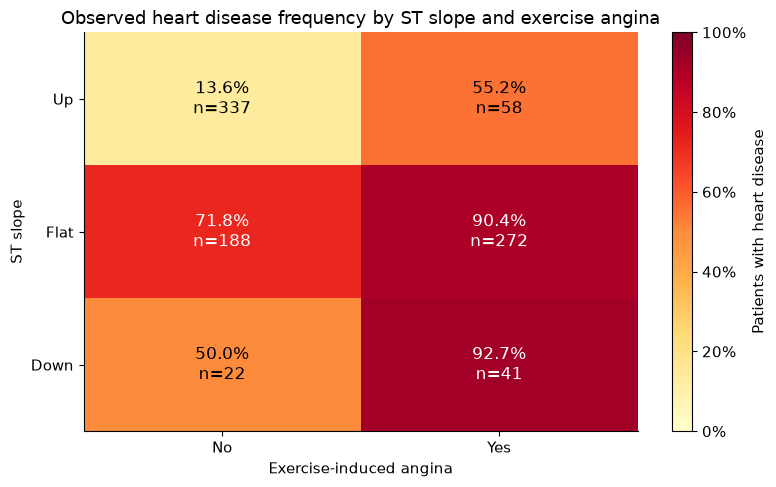

In [6]:
# Each cell estimates an observed P(HeartDisease=1 | two categorical features).
rates = df.pivot_table(index="ST_Slope", columns="ExerciseAngina",
                      values="HeartDisease", aggfunc="mean").reindex(index=["Up", "Flat", "Down"], columns=["N", "Y"])
counts = df.pivot_table(index="ST_Slope", columns="ExerciseAngina",
                       values="HeartDisease", aggfunc="count").reindex(index=rates.index, columns=rates.columns)
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(rates.to_numpy() * 100, cmap="YlOrRd", vmin=0, vmax=100, aspect="auto")
for i in range(len(rates.index)):
    for j in range(len(rates.columns)):
        value, n = rates.iloc[i, j], counts.iloc[i, j]
        text = f"{value:.1%}\nn={int(n)}" if pd.notna(value) else "No observations"
        ax.text(j, i, text, ha="center", va="center",
                color="white" if pd.notna(value) and value > 0.65 else "black", fontsize=12)
ax.set_xticks([0, 1], ["No", "Yes"])
ax.set_yticks([0, 1, 2], rates.index)
ax.set(title="Observed heart disease frequency by ST slope and exercise angina",
       xlabel="Exercise-induced angina", ylabel="ST slope")
fig.colorbar(im, ax=ax, format=PercentFormatter(100), label="Patients with heart disease")
save_plot(fig, "03_st_slope_exercise_angina.png")


Plot 4: Compare medians, spreads, and overlap. A box spans the middle 50%; whiskers extend to observations within 1.5 times the interquartile range. Points beyond them are not automatically errors.

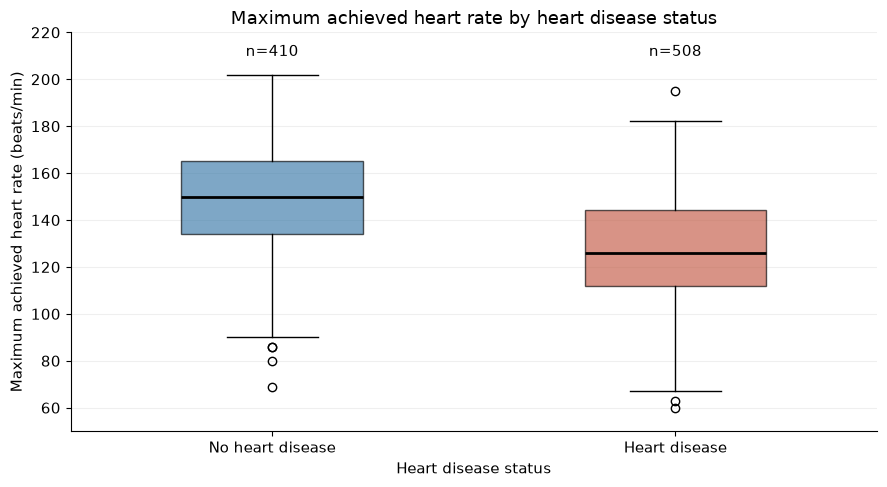

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
groups = [df.loc[df["HeartDisease"].eq(k), "MaxHR"].dropna() for k in [0, 1]]
boxes = ax.boxplot(groups, tick_labels=["No heart disease", "Heart disease"],
                   patch_artist=True, widths=0.45,
                   medianprops={"color": "black", "linewidth": 2})
for box, color in zip(boxes["boxes"], colors):
    box.set_facecolor(color)
    box.set_alpha(0.65)
for pos, values in enumerate(groups, 1):
    ax.text(pos, 0.97, f"n={len(values)}", transform=ax.get_xaxis_transform(),
            ha="center", va="top")
ax.set(title="Maximum achieved heart rate by heart disease status",
       xlabel="Heart disease status", ylabel="Maximum achieved heart rate (beats/min)",
       ylim=(50, 220))
ax.grid(axis="y", alpha=0.2)
save_plot(fig, "04_maxhr_by_heart_disease.png")


### EDA interpretation
Patients with heart disease tend to be older: their median age is 57 years, compared with 51 years in the no-disease group, although the distributions overlap. The ASY chest-pain category has a higher observed disease frequency (79.0%) than ATA (13.9%), NAP (35.5%), or TA (43.5%), and ASY describes the recorded chest-pain category rather than the absence of disease. Flat ST slope and exercise-induced angina are associated with higher disease frequencies; the Flat/angina group has 90.4% disease compared with 71.8% for Flat/no angina. The maximum achieved heart rate is lower in the disease group (median 126 versus 150 beats/min), with substantial overlap between groups. These are associations in a selected sample, not independent causal effects or population risk estimates.

## 2. Bayesian network structure learning
All 11 predictors are retained, with continuous measurements discretized to keep CPT sizes manageable. The following bins are explicit analysis choices rather than validated diagnostic cutoffs: Age `<40`, `40–59`, `60+`; BP `<120`, `120–139`, `140+`; cholesterol `<200`, `200–239`, `240+` mg/dL; maximum achieved HR `<120`, `120–159`, `160+`; and Oldpeak `<1`, `1–<2`, `2+`. Blood pressure and cholesterol values of zero become an `Unknown` category. ExerciseAngina is recoded from N/Y to 0/1 to match the assignment queries; FastingBS is already a binary category.

A fixed, stratified 70/30 split is created **before structure learning**. All three candidate graphs are learned using only the training patients. Hill climbing optimizes BIC with at most three parents and forbids incoming edges to Age and Sex, reflecting their role as pre-existing demographic attributes. Chow–Liu maximizes mutual information along a spanning tree rooted at Age. Tree-Augmented Naive Bayes (TAN) treats HeartDisease as the class node, connects it to every predictor, and adds one tree of conditional dependencies among predictors. These graphs encode statistical dependencies, not proven causal mechanisms. The bin boundaries and state labels are fixed before examining test outcomes.

In [8]:
import numpy as np
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from pgmpy.estimators import HillClimbSearch, TreeSearch, ExpertKnowledge, BayesianEstimator, BIC
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
from IPython.display import Markdown, display

def prepare_data(raw):
    out = raw[["Sex", "ChestPainType", "FastingBS", "RestingECG", "ST_Slope", "HeartDisease"]].copy()
    out["ExerciseAngina"] = raw["ExerciseAngina"].map({"N": 0, "Y": 1})
    specs = {
        "Age": ([float("-inf"), 40, 60, float("inf")], ["<40", "40-59", "60+"]),
        "RestingBP": ([float("-inf"), 120, 140, float("inf")], ["Normal", "Elevated", "High"]),
        "Cholesterol": ([float("-inf"), 200, 240, float("inf")], ["Normal", "Borderline", "High"]),
        "MaxHR": ([float("-inf"), 120, 160, float("inf")], ["Low", "Medium", "High"]),
        "Oldpeak": ([float("-inf"), 1, 2, float("inf")], ["Low", "Medium", "High"]),
    }
    for col, (edges, labels) in specs.items():
        values = raw[col].mask(raw[col].eq(0)) if col in ["RestingBP", "Cholesterol"] else raw[col]
        out[col + "_bin"] = pd.cut(values, bins=edges, labels=labels, right=False).astype(object).fillna("Unknown")
    assert not out.isna().any().any()
    return out

model_data = prepare_data(df)
states = {
    "Sex": ["F", "M"], "ChestPainType": ["ASY", "ATA", "NAP", "TA"],
    "FastingBS": [0, 1], "RestingECG": ["LVH", "Normal", "ST"],
    "ST_Slope": ["Down", "Flat", "Up"], "HeartDisease": [0, 1],
    "ExerciseAngina": [0, 1], "Age_bin": ["<40", "40-59", "60+"],
    "RestingBP_bin": ["Normal", "Elevated", "High", "Unknown"],
    "Cholesterol_bin": ["Normal", "Borderline", "High", "Unknown"],
    "MaxHR_bin": ["Low", "Medium", "High"], "Oldpeak_bin": ["Low", "Medium", "High"],
}
for col in model_data:
    assert set(model_data[col]).issubset(states[col])
    model_data[col] = pd.Categorical(model_data[col], categories=states[col])
train_data, test_data = train_test_split(model_data, test_size=0.30, random_state=42,
                                        stratify=model_data["HeartDisease"])
assert set(train_data.index).isdisjoint(test_data.index)
print(f"Training patients: {len(train_data)}; test patients: {len(test_data)}")
display(model_data.head())

forbidden = [(a, b) for a in model_data.columns for b in ["Age_bin", "Sex"] if a != b]
hill_graph = HillClimbSearch(train_data).estimate(scoring_method="bic-d", max_indegree=3,
               expert_knowledge=ExpertKnowledge(forbidden_edges=forbidden), show_progress=False)
tree_graph = TreeSearch(train_data, root_node="Age_bin", n_jobs=1).estimate(
               estimator_type="chow-liu", show_progress=False)
tan_graph = TreeSearch(train_data, root_node="Age_bin", n_jobs=1).estimate(
               estimator_type="tan", class_node="HeartDisease", show_progress=False)
for graph in [hill_graph, tree_graph, tan_graph]:
    graph.add_nodes_from(model_data.columns)
    assert nx.is_directed_acyclic_graph(graph)
score = BIC(train_data)
display(pd.DataFrame([
    {"Algorithm": "Hill climbing (BIC)", "Edges": len(hill_graph.edges()), "Training BIC": score.score(hill_graph)},
    {"Algorithm": "Chow-Liu", "Edges": len(tree_graph.edges()), "Training BIC": score.score(tree_graph)},
    {"Algorithm": "TAN", "Edges": len(tan_graph.edges()), "Training BIC": score.score(tan_graph)},
]))
print("Hill climbing edges:", sorted(hill_graph.edges()))
print("Chow-Liu edges:", sorted(tree_graph.edges()))
print("TAN edges:", sorted(tan_graph.edges()))


Training patients: 642; test patients: 276


,Sex,ChestPainType,FastingBS,RestingECG,ST_Slope,HeartDisease,ExerciseAngina,Age_bin,RestingBP_bin,Cholesterol_bin,MaxHR_bin,Oldpeak_bin
0,M,ATA,0,Normal,Up,0,0,40-59,High,High,High,Low
1,F,NAP,0,Normal,Flat,1,0,40-59,High,Normal,Medium,Medium
2,M,ATA,0,ST,Up,0,0,<40,Elevated,High,Low,Low
3,F,ASY,0,Normal,Flat,1,1,40-59,Elevated,Borderline,Low,Medium
4,M,NAP,0,Normal,Up,0,0,40-59,High,Normal,Medium,Low


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'C', 'ChestPainType': 'C', 'FastingBS': 'C', 'RestingECG': 'C', 'ST_Slope': 'C', 'HeartDisease': 'C', 'ExerciseAngina': 'C', 'Age_bin': 'C', 'RestingBP_bin': 'C', 'Cholesterol_bin': 'C', 'MaxHR_bin': 'C', 'Oldpeak_bin': 'C'}


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'C', 'ChestPainType': 'C', 'FastingBS': 'C', 'RestingECG': 'C', 'ST_Slope': 'C', 'HeartDisease': 'C', 'ExerciseAngina': 'C', 'Age_bin': 'C', 'RestingBP_bin': 'C', 'Cholesterol_bin': 'C', 'MaxHR_bin': 'C', 'Oldpeak_bin': 'C'}


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'C', 'ChestPainType': 'C', 'FastingBS': 'C', 'RestingECG': 'C', 'ST_Slope': 'C', 'HeartDisease': 'C', 'ExerciseAngina': 'C', 'Age_bin': 'C', 'RestingBP_bin': 'C', 'Cholesterol_bin': 'C', 'MaxHR_bin': 'C', 'Oldpeak_bin': 'C'}


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'C', 'ChestPainType': 'C', 'FastingBS': 'C', 'RestingECG': 'C', 'ST_Slope': 'C', 'HeartDisease': 'C', 'ExerciseAngina': 'C', 'Age_bin': 'C', 'RestingBP_bin': 'C', 'Cholesterol_bin': 'C', 'MaxHR_bin': 'C', 'Oldpeak_bin': 'C'}


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'C', 'ChestPainType': 'C', 'FastingBS': 'C', 'RestingECG': 'C', 'ST_Slope': 'C', 'HeartDisease': 'C', 'ExerciseAngina': 'C', 'Age_bin': 'C', 'RestingBP_bin': 'C', 'Cholesterol_bin': 'C', 'MaxHR_bin': 'C', 'Oldpeak_bin': 'C'}


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'C', 'ChestPainType': 'C', 'FastingBS': 'C', 'RestingECG': 'C', 'ST_Slope': 'C', 'HeartDisease': 'C', 'ExerciseAngina': 'C', 'Age_bin': 'C', 'RestingBP_bin': 'C', 'Cholesterol_bin': 'C', 'MaxHR_bin': 'C', 'Oldpeak_bin': 'C'}


,Algorithm,Edges,Training BIC
0,Hill climbing (BIC),15,-6355.169594
1,Chow-Liu,11,-6359.224538
2,TAN,21,-6385.965180


Hill climbing edges: [('Age_bin', 'Oldpeak_bin'), ('Age_bin', 'RestingBP_bin'), ('Age_bin', 'RestingECG'), ('Cholesterol_bin', 'FastingBS'), ('ExerciseAngina', 'ChestPainType'), ('ExerciseAngina', 'MaxHR_bin'), ('HeartDisease', 'ChestPainType'), ('HeartDisease', 'Cholesterol_bin'), ('HeartDisease', 'ExerciseAngina'), ('HeartDisease', 'FastingBS'), ('Oldpeak_bin', 'ExerciseAngina'), ('Oldpeak_bin', 'ST_Slope'), ('ST_Slope', 'HeartDisease'), ('ST_Slope', 'MaxHR_bin'), ('Sex', 'HeartDisease')]
Chow-Liu edges: [('Age_bin', 'MaxHR_bin'), ('Age_bin', 'RestingBP_bin'), ('Cholesterol_bin', 'FastingBS'), ('Cholesterol_bin', 'RestingECG'), ('HeartDisease', 'ChestPainType'), ('HeartDisease', 'Cholesterol_bin'), ('HeartDisease', 'ExerciseAngina'), ('HeartDisease', 'Sex'), ('MaxHR_bin', 'ST_Slope'), ('ST_Slope', 'HeartDisease'), ('ST_Slope', 'Oldpeak_bin')]
TAN edges: [('Age_bin', 'MaxHR_bin'), ('Age_bin', 'RestingBP_bin'), ('Age_bin', 'RestingECG'), ('Cholesterol_bin', 'FastingBS'), ('Cholesterol_

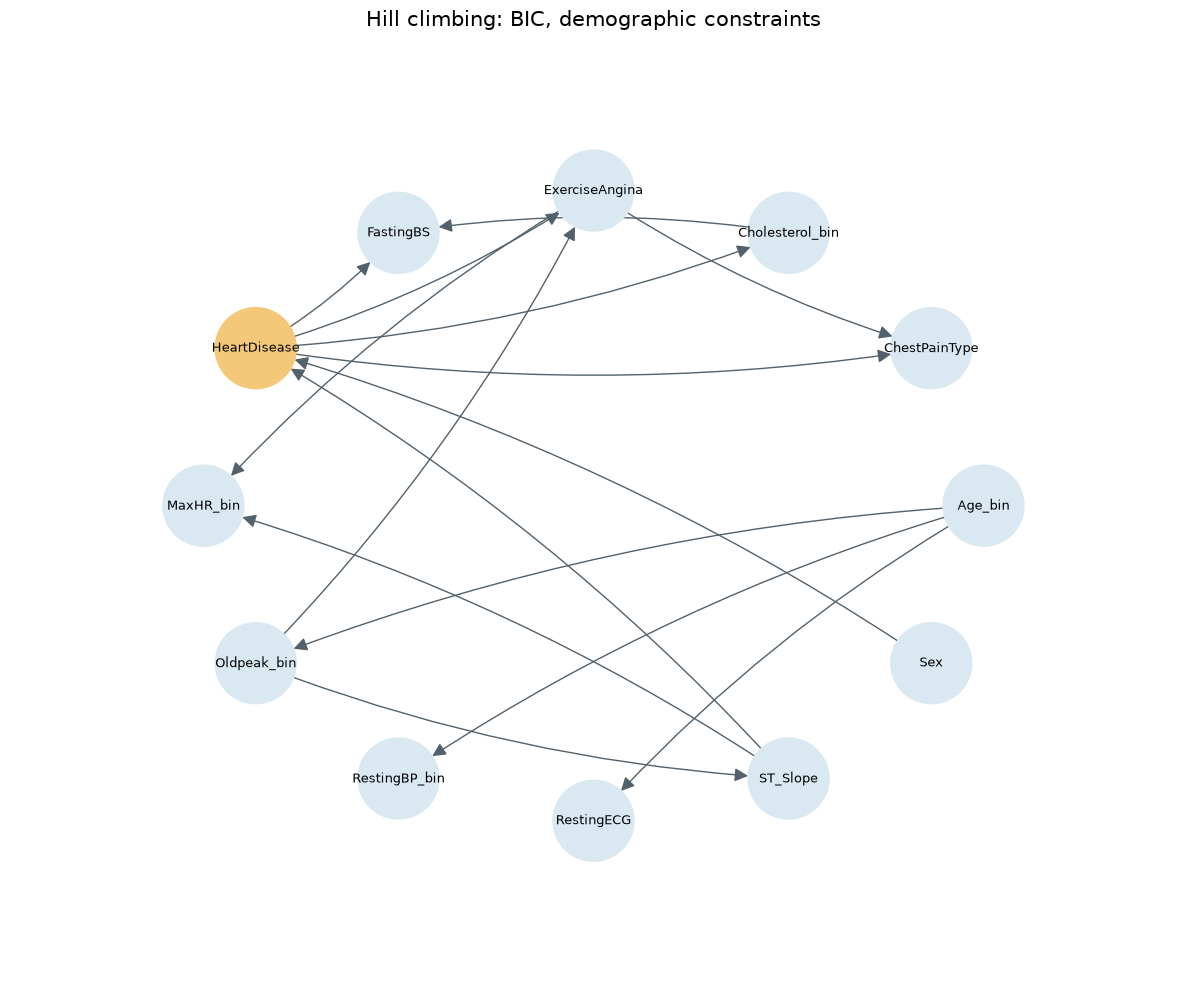

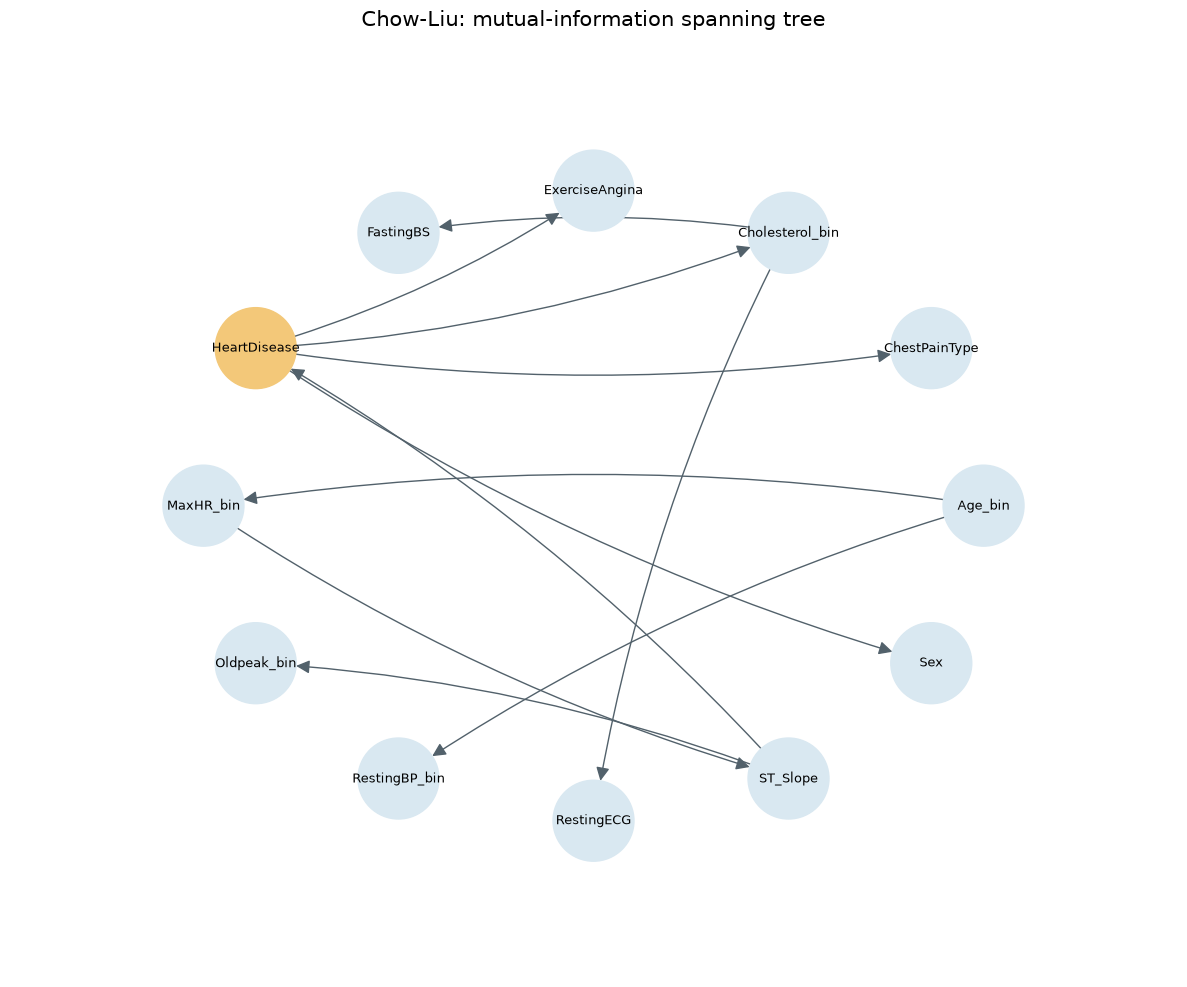

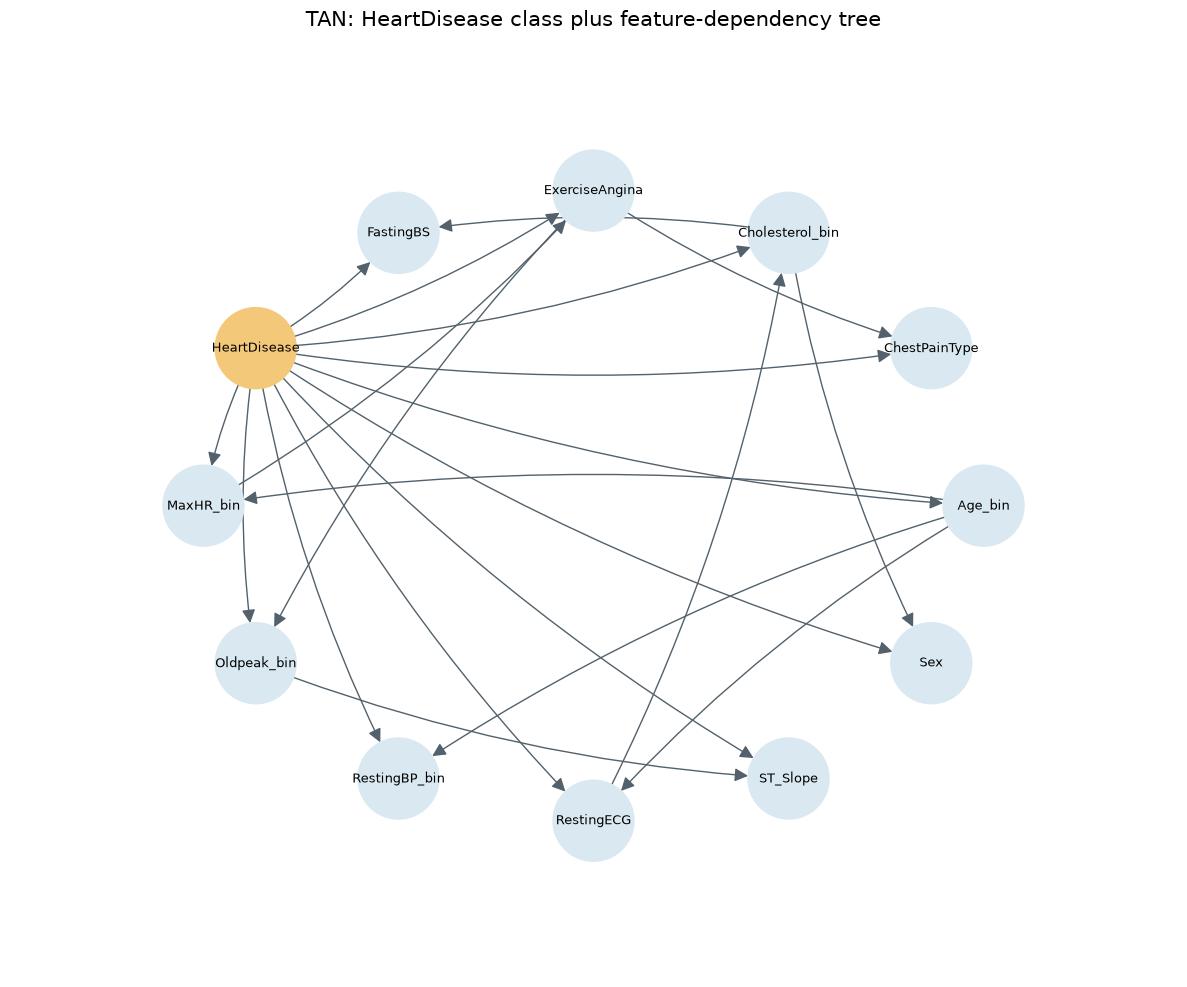

In [9]:
# Shared node locations make the two graphs easier to compare.
pos = nx.circular_layout(sorted(model_data.columns))
for title, graph, filename in [
    ("Hill climbing: BIC, demographic constraints", hill_graph, "05_hill_climbing_network.png"),
    ("Chow-Liu: mutual-information spanning tree", tree_graph, "06_chow_liu_network.png"),
    ("TAN: HeartDisease class plus feature-dependency tree", tan_graph, "07_tan_network.png"),
]:
    fig, ax = plt.subplots(figsize=(12, 10))
    nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=3400,
        node_color=["#F3C879" if node == "HeartDisease" else "#D9E8F1" for node in graph.nodes()])
    nx.draw_networkx_labels(graph, pos, ax=ax, font_size=9)
    nx.draw_networkx_edges(graph, pos, ax=ax, arrows=True, arrowsize=20,
        node_size=3400, connectionstyle="arc3,rad=0.08", edge_color="#52616B")
    ax.set_title(title, fontsize=15)
    ax.axis("off")
    ax.margins(0.18)
    save_plot(fig, filename)


### Final structure choice
I select the constrained hill-climbing graph because it permits multiple dependencies while explicitly preventing symptoms or test findings from pointing into age or sex. Chow–Liu forces every variable into one connected tree, while TAN forces HeartDisease to be a parent of every predictor; both assumptions can impose clinically awkward arrows. Limiting hill climbing to three parents also reduces sparse CPTs and keeps local relationships inspectable. This is a clinically motivated modeling preference made before test evaluation; the remaining learned arrows are statistical factorizations, not established causal directions.

## 3. Parameter learning and clinical inference
The selected **training-learned structure** is held fixed and its CPTs are now fitted to all 918 patients as requested. BDeu parameter estimation uses an equivalent sample size of 5: symmetric Dirichlet pseudo-counts spread across each node's parent configurations and states. This smoothing prevents unseen configurations from receiving automatic zero probabilities; it does not establish calibrated clinical uncertainty. Inference uses variable elimination to sum over unspecified variables.

All CPTs are exported to `results/full_data_cpts.json`, and the HeartDisease CPT is displayed below. A posterior here is a model probability conditional on evidence, not a confidence interval or a future-event risk.

In [10]:
import json
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

def fit_network(data):
    network = DiscreteBayesianNetwork(hill_graph.edges())
    network.add_nodes_from(model_data.columns)
    network.fit(data, estimator=BayesianEstimator, state_names=states,
                prior_type="BDeu", equivalent_sample_size=5, n_jobs=1)
    assert network.check_model()
    for cpd in network.get_cpds():
        assert np.allclose(cpd.get_values().sum(axis=0), 1)
    return network

full_model = fit_network(model_data)
full_inference = VariableElimination(full_model)
print(full_model.get_cpds("HeartDisease"))
cpd_export = {cpd.variable: {"variables": cpd.variables,
              "state_names": cpd.state_names, "values": cpd.values.tolist()}
              for cpd in full_model.get_cpds()}
(results_dir / "full_data_cpts.json").write_text(json.dumps(cpd_export, indent=2), encoding="utf-8")

def probability(inference, evidence):
    factor = inference.query(variables=["HeartDisease"], evidence=evidence, show_progress=False)
    return float(factor.get_value(HeartDisease=1))

queries = {
    "a": {"Age_bin": "60+", "ST_Slope": "Flat"},
    "b": {"Age_bin": "60+", "ST_Slope": "Flat", "ExerciseAngina": 1},
    "c": {"Cholesterol_bin": "High", "MaxHR_bin": "Low"},
    "d": {"ChestPainType": "ATA", "ExerciseAngina": 0},
    "e": {"Age_bin": "60+", "ST_Slope": "Flat", "ExerciseAngina": 1, "Oldpeak_bin": "High"},
}
query_results = []
for label, evidence in queries.items():
    matches = pd.Series(True, index=model_data.index)
    for key, value in evidence.items():
        matches &= model_data[key].eq(value)
    query_results.append({"Query": label, "Evidence": str(evidence),
        "P(HeartDisease=1)": probability(full_inference, evidence),
        "Matching patients": int(matches.sum()),
        "Observed frequency (not model posterior)": model_data.loc[matches, "HeartDisease"].astype(int).mean()})
query_table = pd.DataFrame(query_results).set_index("Query")
display(query_table)
query_table.to_csv(results_dir / "clinical_queries.csv")
p = query_table["P(HeartDisease=1)"].to_dict()

def change(new, old):
    delta = 100 * (new - old)
    return f"{abs(delta):.2f} percentage points {'higher' if delta >= 0 else 'lower'}"

interpretations = {
"a": f"For a patient aged 60 or above with Flat ST slope, the network estimates a {p['a']:.2%} probability of heart disease. Other features are unobserved and marginalized, so this is not the probability for a fully described patient.",
"b": f"Adding exercise-induced angina gives a probability of {p['b']:.2%}, {change(p['b'], p['a'])} than query a. This quantifies how the network updates the same partial patient profile after additional evidence, not the causal effect of angina.",
"c": f"For cholesterol at least 240 mg/dL and maximum achieved HR below 120 beats/min, the estimated probability is {p['c']:.2%}. These fixed bin definitions determine which evidence is entered; age, symptoms, and the remaining features are marginalized.",
"d": f"For atypical angina (ATA) and no exercise-induced angina, the estimated probability is {p['d']:.2%}. This describes the joint evidence pattern and does not mean that either feature rules out disease.",
"e": f"With age 60+, Flat ST slope, exercise-induced angina, and Oldpeak at least 2, the estimated probability is {p['e']:.2%}, {change(p['e'], p['b'])} than query b. Although the prompt calls this a full diagnostic, several features remain unspecified, and the result is a model estimate rather than a definitive diagnosis.",
}
for label, interpretation in interpretations.items():
    display(Markdown(f"**Query {label}:** {interpretation}"))
display(Markdown("Matching-patient counts describe support for each evidence combination. The model can differ from the raw subgroup frequency because it uses a factorized distribution and smoothing; sparse groups warrant extra caution."))


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'C', 'ChestPainType': 'C', 'FastingBS': 'C', 'RestingECG': 'C', 'ST_Slope': 'C', 'HeartDisease': 'C', 'ExerciseAngina': 'C', 'Age_bin': 'C', 'RestingBP_bin': 'C', 'Cholesterol_bin': 'C', 'MaxHR_bin': 'C', 'Oldpeak_bin': 'C'}


+-----------------+-----+--------------------+
| ST_Slope        | ... | ST_Slope(Up)       |
+-----------------+-----+--------------------+
| Sex             | ... | Sex(M)             |
+-----------------+-----+--------------------+
| HeartDisease(0) | ... | 0.7457577530719719 |
+-----------------+-----+--------------------+
| HeartDisease(1) | ... | 0.2542422469280281 |
+-----------------+-----+--------------------+


,Evidence,P(HeartDisease=1),Matching patients,Observed frequency (not model posterior)
Query,,,,
a,"{'Age_bin': '60+', 'ST_Slope': 'Flat'}",0.809592,150,0.866667
b,"{'Age_bin': '60+', 'ST_Slope': 'Flat', 'Exerci...",0.911876,91,0.934066
c,"{'Cholesterol_bin': 'High', 'MaxHR_bin': 'Low'}",0.687475,74,0.783784
d,"{'ChestPainType': 'ATA', 'ExerciseAngina': 0}",0.103248,156,0.096154
e,"{'Age_bin': '60+', 'ST_Slope': 'Flat', 'Exerci...",0.896286,23,1.000000


**Query a:** For a patient aged 60 or above with Flat ST slope, the network estimates a 80.96% probability of heart disease. Other features are unobserved and marginalized, so this is not the probability for a fully described patient.

**Query b:** Adding exercise-induced angina gives a probability of 91.19%, 10.23 percentage points higher than query a. This quantifies how the network updates the same partial patient profile after additional evidence, not the causal effect of angina.

**Query c:** For cholesterol at least 240 mg/dL and maximum achieved HR below 120 beats/min, the estimated probability is 68.75%. These fixed bin definitions determine which evidence is entered; age, symptoms, and the remaining features are marginalized.

**Query d:** For atypical angina (ATA) and no exercise-induced angina, the estimated probability is 10.32%. This describes the joint evidence pattern and does not mean that either feature rules out disease.

**Query e:** With age 60+, Flat ST slope, exercise-induced angina, and Oldpeak at least 2, the estimated probability is 89.63%, 1.56 percentage points lower than query b. Although the prompt calls this a full diagnostic, several features remain unspecified, and the result is a model estimate rather than a definitive diagnosis.

Matching-patient counts describe support for each evidence combination. The model can differ from the raw subgroup frequency because it uses a factorized distribution and smoothing; sparse groups warrant extra caution.

### Answers to queries a-e

**Query a:** For a patient aged 60 or above with Flat ST slope, the network estimates a 80.96% probability of heart disease. Other features are unobserved and marginalized, so this is not the probability for a fully described patient.

**Query b:** Adding exercise-induced angina gives a probability of 91.19%, 10.23 percentage points higher than query a. This quantifies how the network updates the same partial patient profile after additional evidence, not the causal effect of angina.

**Query c:** For cholesterol at least 240 mg/dL and maximum achieved HR below 120 beats/min, the estimated probability is 68.75%. These fixed bin definitions determine which evidence is entered; age, symptoms, and the remaining features are marginalized.

**Query d:** For atypical angina (ATA) and no exercise-induced angina, the estimated probability is 10.32%. This describes the joint evidence pattern and does not mean that either feature rules out disease.

**Query e:** With age 60+, Flat ST slope, exercise-induced angina, and Oldpeak at least 2, the estimated probability is 89.63%, 1.56 percentage points lower than query b. Although the prompt calls this a full diagnostic, several features remain unspecified, and the result is a model estimate rather than a definitive diagnosis.

Matching-patient counts describe support for each evidence combination. The model can differ from the raw subgroup frequency because it uses a factorized distribution and smoothing; sparse groups warrant extra caution.

In query e, the added High Oldpeak evidence lowers the estimate slightly rather than increasing it. The model does not impose monotonic risk effects, and only 23 patients have this complete evidence combination; this result should therefore be interpreted in light of the learned dependencies, smoothing, and limited subgroup support.

## 4. Probabilistic classifier and held-out evaluation
For each patient, inference conditions on all 11 observed, discretized predictors. A probability strictly greater than 0.5 produces prediction 1; exactly 0.5 produces 0. The full-data model generates probabilities for every patient to satisfy the assignment, but these are in-sample predictions and are not used for the reported test metrics.

A second model uses the same training-learned structure, with CPTs fitted **only to the 642 training patients**. Accuracy and ROC AUC are reported on the 276 held-out patients. No test outcomes are used to learn the structure, fit CPTs, choose bins, select the model, or select the threshold.

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'C', 'ChestPainType': 'C', 'FastingBS': 'C', 'RestingECG': 'C', 'ST_Slope': 'C', 'HeartDisease': 'C', 'ExerciseAngina': 'C', 'Age_bin': 'C', 'RestingBP_bin': 'C', 'Cholesterol_bin': 'C', 'MaxHR_bin': 'C', 'Oldpeak_bin': 'C'}


,Training patients,Test patients,Accuracy,ROC AUC,Majority baseline accuracy
0,642,276,0.873188,0.939423,0.554348


The held-out classifier achieves **87.32% accuracy** and **0.9394 ROC AUC**, compared with **55.43% accuracy** for always predicting the training majority class. At the specified threshold it produces 138 true positives, 103 true negatives, 20 false positives, and 15 false negatives. AUC measures ranking discrimination rather than probability calibration; one split in this small sample does not establish performance in another hospital or population.

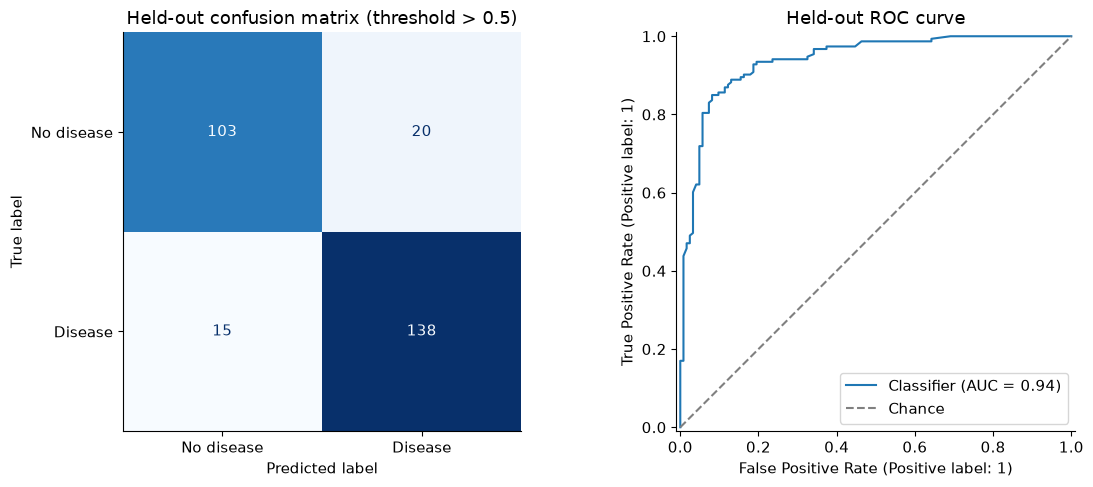

In [11]:
feature_cols = [col for col in model_data if col != "HeartDisease"]
def predict_probabilities(inference, frame):
    # Cache repeated feature combinations, but preserve original patient order.
    cache = {}
    values = []
    for row in frame[feature_cols].itertuples(index=False, name=None):
        if row not in cache:
            cache[row] = probability(inference, dict(zip(feature_cols, row)))
        values.append(cache[row])
    return np.asarray(values)

all_probabilities = predict_probabilities(full_inference, model_data)
all_predictions = pd.DataFrame({"Patient row": model_data.index,
    "Actual HeartDisease": model_data["HeartDisease"],
    "Full-data probability (in-sample)": all_probabilities,
    "Full-data prediction": (all_probabilities > 0.5).astype(int)})
all_predictions.to_csv(results_dir / "all_patient_predictions.csv", index=False)

test_model = fit_network(train_data)
test_inference = VariableElimination(test_model)
test_probabilities = predict_probabilities(test_inference, test_data)
test_predictions = (test_probabilities > 0.5).astype(int)
y_test = test_data["HeartDisease"].to_numpy()
assert np.isfinite(test_probabilities).all()
assert ((test_probabilities >= 0) & (test_probabilities <= 1)).all()
accuracy = accuracy_score(y_test, test_predictions)
auc = roc_auc_score(y_test, test_probabilities)
majority = int(train_data["HeartDisease"].mode().iloc[0])
baseline_accuracy = accuracy_score(y_test, np.full(len(test_data), majority))
metrics = {"Training patients": len(train_data), "Test patients": len(test_data),
           "Accuracy": accuracy, "ROC AUC": auc, "Majority baseline accuracy": baseline_accuracy}
display(pd.DataFrame([metrics]))
pd.DataFrame({"Patient row": test_data.index, "Actual HeartDisease": y_test,
              "Probability": test_probabilities, "Prediction": test_predictions}).to_csv(
              results_dir / "held_out_predictions.csv", index=False)
(results_dir / "classifier_metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
tn, fp, fn, tp = confusion_matrix(y_test, test_predictions, labels=[0, 1]).ravel()
display(Markdown(f"The held-out classifier achieves **{accuracy:.2%} accuracy** and **{auc:.4f} ROC AUC**, compared with **{baseline_accuracy:.2%} accuracy** for always predicting the training majority class. At the specified threshold it produces {tp} true positives, {tn} true negatives, {fp} false positives, and {fn} false negatives. AUC measures ranking discrimination rather than probability calibration; one split in this small sample does not establish performance in another hospital or population."))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, test_predictions, display_labels=["No disease", "Disease"],
                                        ax=axes[0], colorbar=False, cmap="Blues")
RocCurveDisplay.from_predictions(y_test, test_probabilities, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
axes[0].set_title("Held-out confusion matrix (threshold > 0.5)")
axes[1].set_title("Held-out ROC curve")
axes[1].legend()
save_plot(fig, "08_classifier_evaluation.png")


### Classifier results and interpretation

The held-out classifier achieves **87.32% accuracy** and **0.9394 ROC AUC**, compared with **55.43% accuracy** for always predicting the training majority class. At the specified threshold it produces 138 true positives, 103 true negatives, 20 false positives, and 15 false negatives. AUC measures ranking discrimination rather than probability calibration; one split in this small sample does not establish performance in another hospital or population.

## 5. Discussion
### Why might a hospital prefer the Bayesian network?
A cardiologist can inspect this network's graph, conditional probability tables, and the way additional evidence changes a patient's modeled probability. The network also supports inference with partially observed patient features instead of requiring every input, and its assumptions can be reviewed with domain experts. Those properties may support clinical review, auditability, and communication even if another model has 3–5 percentage points higher accuracy. However, a preference should also consider false-negative and false-positive costs, calibration, subgroup performance, and external validation; an interpretable graph does not automatically establish causality or safety.

### Real-world example in 2025
**Infermedica** is a medical triage and care-navigation company whose inference engine uses modified Bayesian networks alongside other machine-learning methods. It updates assessments using symptoms, risk factors, and demographic information, asks follow-up questions, and recommends an appropriate level of care. Its real-world use in 2025 is documented by a publication describing Healthdirect Australia's national virtual front door; this is deployed triage support, rather than a claim that the classroom model is clinically validated. Sources: [Infermedica's inference-engine description](https://infermedica.com/inference-engine) and [McMahon and McInerney (2025), deployment publication listed on Infermedica's research page](https://infermedica.com/research-studies).

### Technical references
- [pgmpy 1.0 HillClimbSearch](https://pgmpy.org/_modules/pgmpy/estimators/HillClimbSearch.html)
- [pgmpy TreeSearch: Chow–Liu and TAN](https://pgmpy.org/_modules/pgmpy/estimators/TreeSearch.html)
- [KaggleHub loading documentation](https://github.com/Kaggle/kagglehub#load-dataset)

### Limitations
Discretization discards measurement detail, results depend on the graph and smoothing choices, and treating unknown measurements as a category may capture collection practices. Learned arrows are associations; no causal discovery claim is made. The split is reproducible but comes from the same dataset, with no external validation or calibration study.